In [182]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

In [183]:
citra1 = plt.imread("brandnewday.jpg")
citra2 = cv.imread('brandnewday.jpg')


Text(0.5, 1.0, 'gambarB')

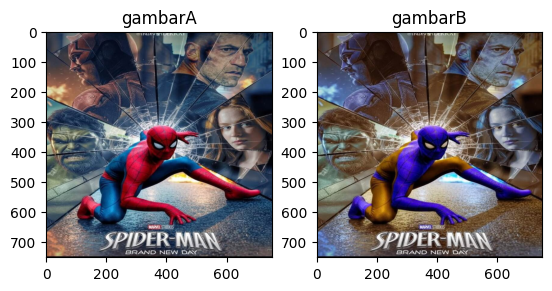

In [184]:
plt.subplot(1, 2, 1)
plt.imshow(citra1)
plt.title('gambarA')

plt.subplot(1, 2, 2)
plt.imshow(citra2)
plt.title('gambarB')

In [185]:
merahA = citra1[:, :, 0]
hijauA = citra1[:, :, 1]
biruA = citra1[:, :, 2]

In [186]:
merahB = citra2[:, :, 0]
hijauB = citra2[:, :, 1]
biruB = citra2[:, :, 2]

In [187]:
grayA= cv.cvtColor(citra1, cv.COLOR_BGR2GRAY)
grayB = cv.cvtColor(citra2, cv.COLOR_BGR2GRAY)

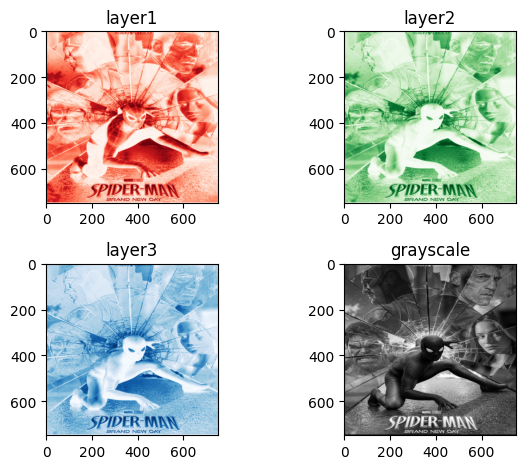

In [188]:
plt.subplot(2, 2, 1)
plt.imshow(merahA, cmap="Reds")
plt.title("layer1")

plt.subplot(2, 2, 2)
plt.imshow(hijauA, cmap="Greens")
plt.title("layer2")

plt.subplot(2, 2, 3)
plt.imshow(biruA, cmap="Blues")
plt.title("layer3")

plt.subplot(2, 2, 4)
plt.imshow(grayA, cmap = "gray")
plt.title("grayscale")
plt.tight_layout()
plt.show()

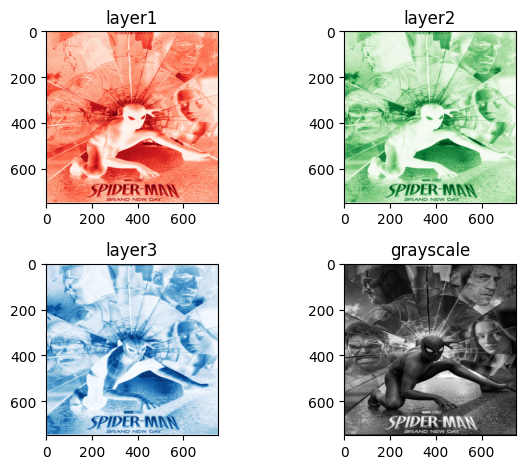

In [189]:
plt.subplot(2, 2, 1)
plt.imshow(merahB, cmap="Reds")
plt.title("layer1")

plt.subplot(2, 2, 2)
plt.imshow(hijauB, cmap="Greens")
plt.title("layer2")

plt.subplot(2, 2, 3)
plt.imshow(biruB, cmap="Blues")
plt.title("layer3")

plt.subplot(2, 2, 4)
plt.imshow(grayB, cmap = "gray")
plt.title("grayscale")
plt.tight_layout()
plt.show()

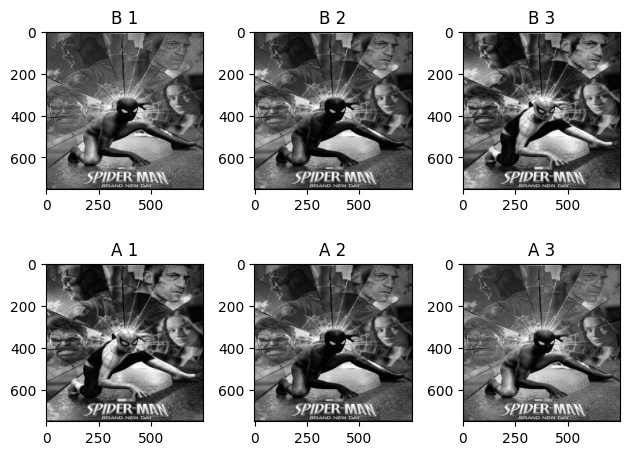

In [190]:
plt.subplot(2, 3, 1)
plt.imshow(merahB,cmap="gray")
plt.title("B 1")

plt.subplot(2, 3, 2)
plt.imshow(hijauB, cmap="gray")
plt.title("B 2")

plt.subplot(2, 3, 3)
plt.imshow(biruB, cmap="gray")
plt.title("B 3")

plt.subplot(2, 3, 4)
plt.imshow(merahA, cmap = "gray")
plt.title("A 1")

plt.subplot(2, 3, 5)
plt.imshow(hijauA, cmap = "gray")
plt.title("A 2")

plt.subplot(2, 3, 6)
plt.imshow(biruA, cmap = "gray")
plt.title("A 3")

plt.tight_layout()
plt.show()

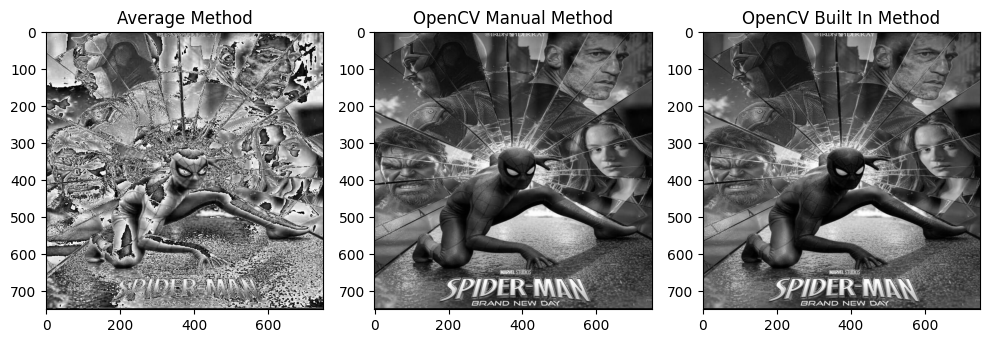

In [191]:
average= ((merahB+hijauB+biruB)/3)

built = 0.299 * merahB + 0.587* hijauB + 0.114 * biruB

manual = cv.cvtColor(citra2, cv.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 8))
plt.subplot(2, 3, 1)
plt.imshow(average,cmap="gray")
plt.title("Average Method")

plt.subplot(2, 3, 2)
plt.imshow(manual, cmap="gray")
plt.title("OpenCV Manual Method")

plt.subplot(2, 3, 3)
plt.imshow(built, cmap="gray")
plt.title("OpenCV Built In Method")
plt.tight_layout()
plt.show()

In [192]:
negatif = 255 - grayB
gn = grayB - negatif
ng = negatif - grayB 

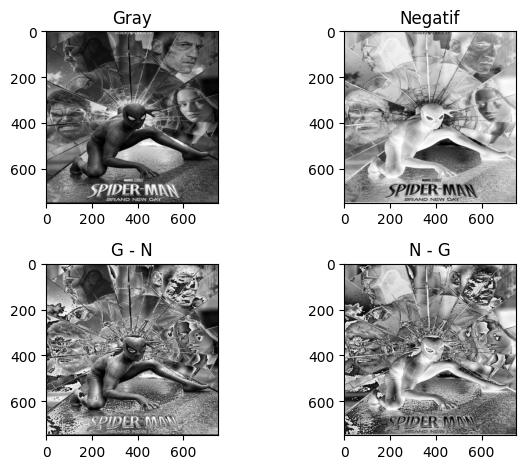

In [193]:
plt.subplot(2, 2, 1)
plt.imshow(grayB, cmap="gray")
plt.title("Gray")

plt.subplot(2, 2, 2)
plt.imshow(negatif, cmap="gray")
plt.title("Negatif")

plt.subplot(2, 2, 3)
plt.imshow(gn, cmap="gray")
plt.title("G - N")

plt.subplot(2, 2, 4)
plt.imshow(ng, cmap = "gray")
plt.title("N - G")
plt.tight_layout()
plt.show()

In [194]:
citra12 = citra1.copy()
citra12[:, :, 0] = grayA

citra13 = citra1.copy()
citra13[:, :, 1] = grayA

citra14 = citra1.copy()
citra14[:, :, 2] = grayA

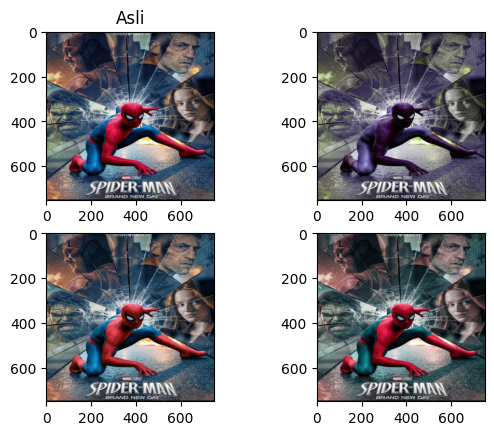

In [195]:
plt.subplot(2, 2, 1)
plt.imshow(citra1)
plt.title("Asli")

plt.subplot(2, 2, 2)
plt.imshow(citra12)

plt.subplot(2, 2, 3)
plt.imshow(citra13)

plt.subplot(2, 2, 4)
plt.imshow(citra14)

plt.show()

In [196]:
def rotasi(image, derajat):
    h, w = image.shape
    
    rad = derajat * np.pi / 180
    cos_a = np.cos(rad)
    sin_a = np.sin(rad)

    cx = w / 2
    cy = h / 2

    rx0 = cos_a * (0 - cx) - sin_a * (0 - cy) + cx
    ry0 = sin_a * (0 - cx) + cos_a * (0 - cy) + cy

    rx1 = cos_a * (w - cx) - sin_a * (0 - cy) + cx
    ry1 = sin_a * (w - cx) + cos_a * (0 - cy) + cy

    rx2 = cos_a * (0 - cx) - sin_a * (h - cy) + cx
    ry2 = sin_a * (0 - cx) + cos_a * (h - cy) + cy

    rx3 = cos_a * (w - cx) - sin_a * (h - cy) + cx
    ry3 = sin_a * (w - cx) + cos_a * (h - cy) + cy

    new_w = int(max([rx0, rx1, rx2, rx3]) - min([rx0, rx1, rx2, rx3])) + 1
    new_h = int(max([ry0, ry1, ry2, ry3]) - min([ry0, ry1, ry2, ry3])) + 1

    ox = (new_w - w) / 2
    oy = (new_h - h) / 2

    hasil = np.zeros((new_h, new_w), dtype=image.dtype)

    for i in range(new_h):
        for j in range(new_w):
            x0 = j - ox - cx
            y0 = i - oy - cy

            xr = int(cos_a * x0 + sin_a * y0 + cx)
            yr = int(-sin_a * x0 + cos_a * y0 + cy)

            if 0 <= xr < w and 0 <= yr < h:
                hasil[i, j] = image[yr, xr]

    return hasil.astype(np.uint8)

In [197]:
rotasiSearah = rotasi(grayB, 13)
rotasiLawan = rotasi(grayB, -13)

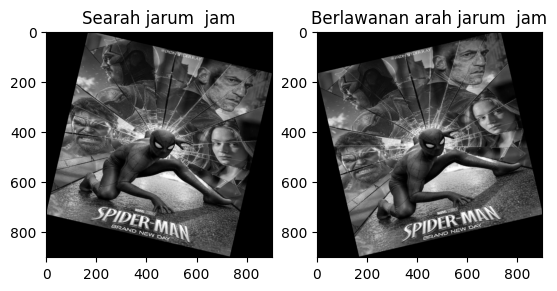

In [198]:
plt.subplot(1, 2, 1)
plt.imshow(rotasiSearah, cmap='gray')
plt.title("Searah jarum  jam")

plt.subplot(1, 2, 2)
plt.imshow(rotasiLawan, cmap='gray')
plt.title("Berlawanan arah jarum  jam")

plt.show()

In [199]:
threshold = 13
height, width = grayB.shape

result = grayB.copy()

for y in range(height):
    for x in range(width):
        if grayB[y][x] >= threshold:
            result[y][x] = 255
        else:
            result[y][x] = 0

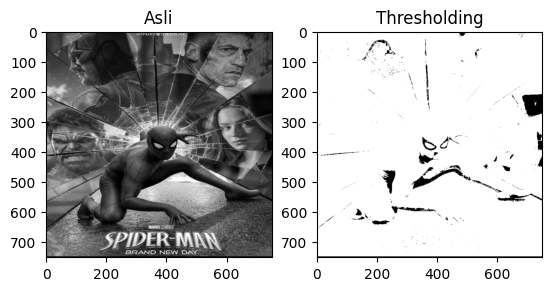

In [200]:
plt.subplot(1, 2, 1)
plt.imshow(grayB, cmap='gray')
plt.title("Asli")

plt.subplot(1, 2, 2)
plt.imshow(result, cmap='gray')
plt.title("Thresholding")

plt.show()

In [201]:
def zero_padding(citra, pad):
    h, w = citra.shape
    hasil = np.zeros((h + 2*pad, w + 2*pad), dtype=citra.dtype)
    hasil[pad:pad+h, pad:pad+w] = citra
    return hasil.astype(np.uint8)

(1050, 1050)


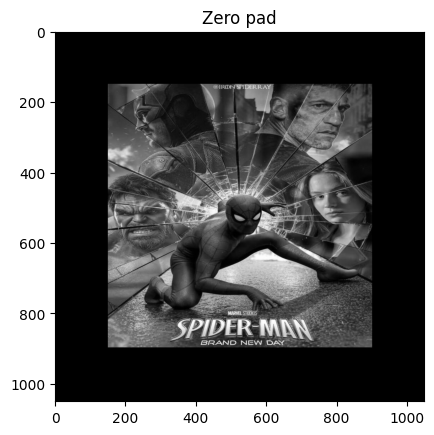

In [202]:
citraZeropad = zero_padding(grayB, 150)
plt.imshow(citraZeropad, cmap='gray')
plt.title("Zero pad")
print(citraZeropad.shape)

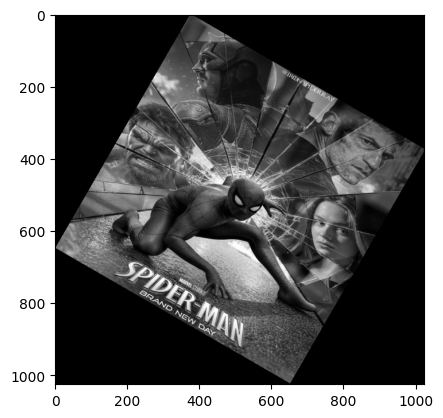

In [203]:
rotasi1 = rotasi(grayB, 30)
plt.imshow(rotasi1, cmap='gray')



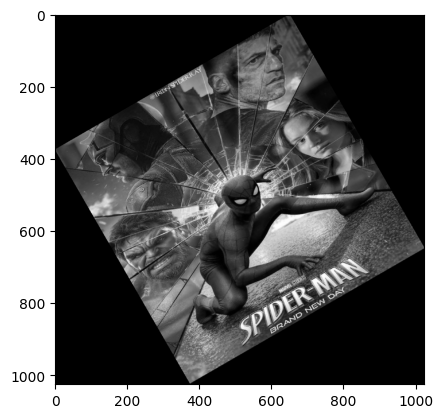

In [204]:
rotasi2 = rotasi(grayB, -30)
plt.imshow(rotasi2, cmap='gray')

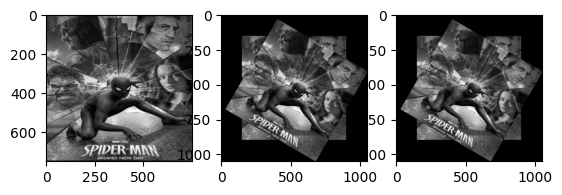

In [222]:
def tumpuk(citra1, citra2):
    h, w = citra1.shape
    hasil = citra1.copy()
    for i in range(h):
        for j in range(w):
            if citra2 [i][j] > 0:
                hasil [i, j]= citra2 [i,j]
    return hasil.astype(np.uint8)

citraZeropad = zero_padding(grayB, 150)

rotasi2 = rotasi(grayB, 30)
rotasin = zero_padding(rotasi2, 30)

tumpuk1 = tumpuk(citraZeropad, rotasin)



plt.subplot(2, 3, 1)
plt.imshow(grayB, cmap='gray')

plt.subplot(2, 3, 2)
plt.imshow(tumpuk1, cmap='gray')

plt.subplot(2, 3, 3)
plt.imshow(tumpuk1, cmap='gray')